# 8. Constrained learning: the third family, on real data

**Claim under test:** pick a fairness criterion, hand it to a library, and the
library handles it.

Notebooks 1, 4 and 5 change the **input** (drop, project, reweigh). Notebooks 3
and 6 and the root notebook change the **output** (thresholds). This one changes
the **fit**, which is the third family and the only one the repo has not run on
real data.

Everything below is `fairlearn` on UCI Adult, predicting income over $50k, with
`sex` as the protected attribute. Five arms on one held-out split:

| arm | family | needs the attribute |
|---|---|---|
| unconstrained | - | never |
| `ExponentiatedGradient`, demographic parity | in-training | at training time |
| `ExponentiatedGradient`, equalised odds | in-training | at training time |
| `ThresholdOptimizer`, demographic parity | post-processing | **at prediction time** |
| `ThresholdOptimizer`, equalised odds | post-processing | **at prediction time** |

That last column is the one that decides what you are allowed to build. Under
the AI Act and GDPR, holding a special category at training time and holding it
at every prediction are different asks, and the second is much harder to justify.

- Agarwal, Beygelzimer, Dudík, Langford & Wallach (2018), *A Reductions Approach
  to Fair Classification* - the `ExponentiatedGradient` method
- Hardt, Price & Srebro (2016), `papers/hardt-2016-equality-of-opportunity.pdf` -
  the `ThresholdOptimizer` method

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from fairlearn.reductions import ExponentiatedGradient, DemographicParity, EqualizedOdds
from fairlearn.postprocessing import ThresholdOptimizer

adult = fetch_openml(data_id=1590, as_frame=True, parser='auto').frame.dropna()
y = adult['class'].astype(str).str.contains('>').values
A = (adult['sex'] == 'Female').map({True: 'Female', False: 'Male'}).values
X = adult.drop(columns=['class'])          # sex stays in, as it would in practice

cats = X.select_dtypes(include=['category', 'object']).columns.tolist()
nums = [c for c in X.columns if c not in cats]
prep = ColumnTransformer(
    [('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cats),
     ('num', StandardScaler(), nums)])

Xtr, Xte, ytr, yte, Atr, Ate = train_test_split(
    X, y, A, test_size=0.4, random_state=0, stratify=y)

# fairlearn's reduction passes sample_weight straight to the estimator, and a
# sklearn Pipeline refuses it, so the encoding is done once up front and the
# estimator is a bare LogisticRegression.
Xtr = prep.fit_transform(Xtr)
Xte = prep.transform(Xte)
print(f'{len(adult)} rows.  train {Xtr.shape[0]}, test {Xte.shape[0]}, '
      f'{Xtr.shape[1]} encoded columns')
print(f'base rate over $50k:  Male {y[A == "Male"].mean():.1%}   '
      f'Female {y[A == "Female"].mean():.1%}')


45222 rows.  train 27133, test 18089, 104 encoded columns
base rate over $50k:  Male 31.2%   Female 11.4%


## The five arms

`ExponentiatedGradient` retrains the base model many times under a Lagrangian on
the constraint, so it is slow and it returns a randomised classifier.
`ThresholdOptimizer` fits the base model once and then chooses per-group
thresholds. Both are given the same base learner so the comparison is about the
method, not the model.

In [2]:
def base():
    return LogisticRegression(max_iter=2000)


def scores(pred, name):
    out = {'arm': name, 'accuracy': (pred == yte).mean()}
    sel = {g: pred[Ate == g].mean() for g in ('Male', 'Female')}
    out['sel ratio'] = min(sel.values()) / max(sel.values())
    for g in ('Male', 'Female'):
        m = Ate == g
        out[f'TPR {g[0]}'] = pred[m & (yte == 1)].mean()
        out[f'FPR {g[0]}'] = pred[m & (yte == 0)].mean()
        out[f'PPV {g[0]}'] = yte[m & pred].mean() if pred[m].any() else np.nan
    return out


rows = []

plain = base().fit(Xtr, ytr)
rows.append(scores(plain.predict(Xte), 'unconstrained'))

for constraint, label in ((DemographicParity(), 'ExpGrad, demographic parity'),
                          (EqualizedOdds(), 'ExpGrad, equalised odds')):
    eg = ExponentiatedGradient(base(), constraints=constraint, max_iter=20)
    eg.fit(Xtr, ytr, sensitive_features=Atr)
    rows.append(scores(eg.predict(Xte, random_state=0).astype(bool), label))

for constraint, label in (('demographic_parity', 'ThreshOpt, demographic parity'),
                          ('equalized_odds', 'ThreshOpt, equalised odds')):
    to = ThresholdOptimizer(estimator=base(), constraints=constraint,
                            prefit=False, predict_method='predict_proba')
    to.fit(Xtr, ytr, sensitive_features=Atr)
    rows.append(scores(to.predict(Xte, sensitive_features=Ate, random_state=0).astype(bool), label))

res = pd.DataFrame(rows).set_index('arm')
pd.set_option('display.width', 200)
print(res.round(3).to_string())


                               accuracy  sel ratio  TPR M  FPR M  PPV M  TPR F  FPR F  PPV F
arm                                                                                         
unconstrained                     0.847      0.325  0.616  0.102  0.731  0.526  0.025  0.738
ExpGrad, demographic parity       0.829      0.992  0.450  0.045  0.820  0.762  0.092  0.531
ExpGrad, equalised odds           0.836      0.524  0.537  0.073  0.770  0.544  0.055  0.572
ThreshOpt, demographic parity     0.824      0.891  0.418  0.038  0.831  0.769  0.095  0.524
ThreshOpt, equalised odds         0.830      0.580  0.506  0.062  0.787  0.501  0.064  0.516


## Read the numbers

In [3]:
print(f"{'arm':<30}{'acc':>7}{'sel ratio':>11}{'TPR gap':>9}{'FPR gap':>9}{'PPV gap':>9}")
for arm, r in res.iterrows():
    print(f"{arm:<30}{r['accuracy']:>7.3f}{r['sel ratio']:>11.2f}"
          f"{abs(r['TPR M'] - r['TPR F']):>9.3f}{abs(r['FPR M'] - r['FPR F']):>9.3f}"
          f"{abs(r['PPV M'] - r['PPV F']):>9.3f}")
print('\nsel ratio is the disparate impact ratio; 0.80 is the four-fifths line')


arm                               acc  sel ratio  TPR gap  FPR gap  PPV gap
unconstrained                   0.847       0.33    0.091    0.077    0.007
ExpGrad, demographic parity     0.829       0.99    0.313    0.047    0.289
ExpGrad, equalised odds         0.836       0.52    0.006    0.017    0.198
ThreshOpt, demographic parity   0.824       0.89    0.351    0.057    0.307
ThreshOpt, equalised odds       0.830       0.58    0.005    0.002    0.270

sel ratio is the disparate impact ratio; 0.80 is the four-fifths line


## What the table says

**The accuracy price is small. The cross-criterion price is not.** Every
constrained arm lands within 0.023 accuracy of the unconstrained model - 0.847
down to 0.824 at worst. That is the number people expect to be large, and it is
not. What moves is everything else.

**The unconstrained model already has predictive parity.** Its PPV gap is
**0.007**, essentially zero, at a selection ratio of **0.33**. Nobody asked for
that. It is the fact notebook 7 measures directly: sufficiency falls out of
unconstrained learning because sex is legible in the features. So the model
arrives satisfying one fairness criterion and failing another by a factor of
three, and which one you notice depends entirely on which one you tested for.

**Enforcing demographic parity destroys predictive parity.** `ExpGrad` takes the
selection ratio from 0.33 to **0.99** and the PPV gap from 0.007 to **0.289**.
"Shortlisted" now means a 82% chance of being over $50k for a man and 53% for a
woman. The TPR gap goes from 0.091 to 0.313 in the same move.

**Enforcing equalised odds does what it says and nothing more.** TPR gap
**0.006**, FPR gap **0.017**, and the selection ratio stays at **0.52** - still
a four-fifths failure. If your regulator screens on the four-fifths rule and your
model is constrained to equalised odds, you fail, and you fail while satisfying
the criterion the fairness literature most often recommends.

**In-training beats post-processing, slightly, on both constraints.** 0.829 vs
0.824 for demographic parity, 0.836 vs 0.830 for equalised odds. That is the
theoretical prediction - a constrained fit can trade across the whole model,
where post-processing can only move two thresholds - and the margin is small
enough that it should not decide anything on its own.

**The column that should decide it is the last one in the table at the top.**
`ThresholdOptimizer` needs the protected attribute at prediction time, for every
applicant, forever. `ExponentiatedGradient` needs it only while training. Under
Article 4a, holding special-category data to correct a bias once is arguable;
holding it to serve every decision is a different system and a different
argument.

## So what does a practitioner do

Pick the criterion **before** looking at the table, in writing, with the reason.
Every arm here is defensible and they contradict each other, so a criterion
chosen after seeing the results is a rationalisation of whichever number came out
well.

Then report all of them anyway. The failure mode this notebook is built to show
is not choosing wrongly; it is reporting only the one you optimised.

## The picture


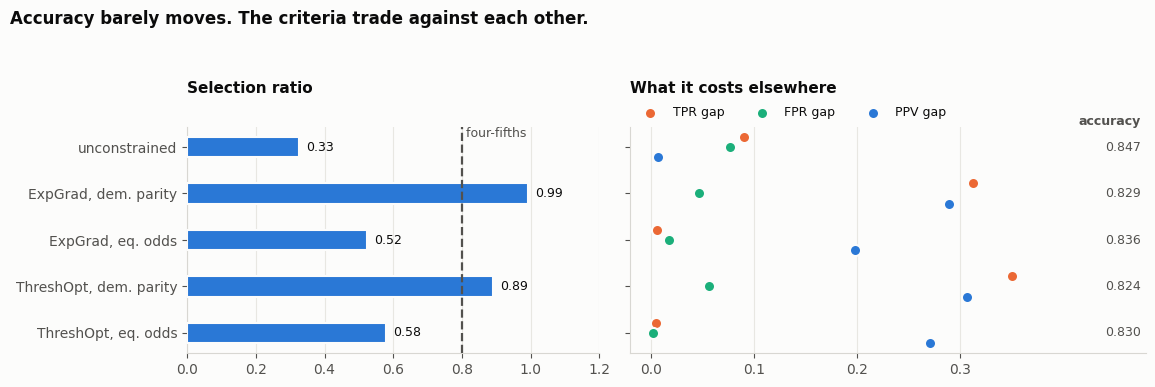

In [4]:
import matplotlib.pyplot as plt

BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, MUTED, SURFACE = '#0b0b0b', '#52514e', '#fcfcfb'
plt.rcParams.update({'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
                     'font.size': 10, 'axes.titlesize': 11, 'axes.titleweight': 'bold',
                     'axes.labelcolor': MUTED, 'text.color': INK,
                     'xtick.color': MUTED, 'ytick.color': MUTED})


def tidy(ax, xgrid=True):
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color('#d8d7d2')
    ax.grid(axis='x' if xgrid else 'y', color='#e8e7e2', lw=0.8)
    ax.set_axisbelow(True)


arms = list(res.index)
short = ['unconstrained', 'ExpGrad, dem. parity', 'ExpGrad, eq. odds',
         'ThreshOpt, dem. parity', 'ThreshOpt, eq. odds']
ypos = np.arange(len(arms))[::-1]

fig, axes = plt.subplots(1, 2, figsize=(11.6, 3.9), sharey=True,
                         gridspec_kw={'width_ratios': [1, 1.25]})

ratios = res['sel ratio'].values
axes[0].barh(ypos, ratios, height=0.44, color=BLUE, zorder=3,
             edgecolor=SURFACE, lw=1.5)
axes[0].axvline(0.8, color=MUTED, lw=1.6, ls='--', zorder=4)
axes[0].text(0.8, 1.0, ' four-fifths', color=MUTED, fontsize=9, va='top', ha='left',
             transform=axes[0].get_xaxis_transform())
for yv, v in zip(ypos, ratios):
    axes[0].text(v + 0.02, yv, f'{v:.2f}', va='center', ha='left',
                 fontsize=9, color=INK)
axes[0].set_yticks(ypos, short)
axes[0].set_xlim(0, 1.2)
tidy(axes[0])
axes[0].set_title('Selection ratio', loc='left', pad=24)

gaps = {'TPR gap': (res['TPR M'] - res['TPR F']).abs().values,
        'FPR gap': (res['FPR M'] - res['FPR F']).abs().values,
        'PPV gap': (res['PPV M'] - res['PPV F']).abs().values}
for (name, vals), colour, off in zip(gaps.items(), (ORANGE, AQUA, BLUE), (0.22, 0, -0.22)):
    axes[1].scatter(vals, ypos + off, s=64, color=colour, label=name,
                    edgecolor=SURFACE, lw=1.5, zorder=3)
for yv, acc in zip(ypos, res['accuracy']):
    axes[1].text(0.475, yv, f'{acc:.3f}', va='center', ha='right',
                 fontsize=9, color=MUTED)
axes[1].text(0.475, len(arms) - 0.45, 'accuracy', va='center', ha='right',
             fontsize=9, color=MUTED, fontweight='bold')
axes[1].legend(frameon=False, ncol=3, fontsize=9, loc='lower left',
               bbox_to_anchor=(0.0, 1.0), borderaxespad=0.2)
axes[1].set_xlim(-0.02, 0.48)
axes[1].set_xticks([0, 0.1, 0.2, 0.3])
tidy(axes[1])
axes[1].set_title('What it costs elsewhere', loc='left', pad=24)

fig.suptitle('Accuracy barely moves. The criteria trade against each other.',
             x=0.008, ha='left', fontsize=12, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig('../figures/08_constraints.png', dpi=150, bbox_inches='tight')
plt.show()
